# TSFresh-Features aus rohem, PCA- und DyCA-gefiltertem TEP-Signal

Umsetzung des zweiten TODO-Punkts aus `LazyClassifier_PCA_DyCA.ipynb`: statt der
**Eigenwerte** werden hier **TSFresh-Features** direkt aus dem Zeitsignal gewonnen —
einmal aus dem ungefilterten Signal, einmal aus dem PCA-projizierten und einmal aus
dem DyCA-projizierten. Anschließend Feature Selection auf die besten `TOP_K` Features
und LazyClassifier.

## Die 11 Konfigurationen

| Konfiguration | Kanäle | Projektion |
|---|---|---|
| `raw` | 52 | keine — die 52 Prozessvariablen direkt |
| `pca_4 … pca_12` | 4, 6, 8, 10, 12 | PCA pro Run, Scores der ersten *n* Hauptkomponenten |
| `dyca_m2_n4 … dyca_m6_n12` | 4, 6, 8, 10, 12 | DyCA pro Run, `amplitudes` (n, time) |

Zusammen 52 + 40 + 40 = **132 Kanäle pro Run**. Die DyCA-Paare sind n = 2m; das ist
exakt der Grenzfall der Bedingung `m >= n - m`, die das `dyca`-Paket erzwingt.

## Vorgehen (dreistufig)

**Phase A — Extraktion + Selektion auf TRAIN.** Je Konfiguration werden alle
TSFresh-Features auf allen Trainingsruns berechnet (`EfficientFCParameters`,
~780 Features je Kanal), daraus per Relevanztabelle die besten `TOP_K` ausgewählt.
Danach wird die volle Matrix sofort verworfen und nur `TOP_K` behalten.

**Phase B — Testset.** `tsfresh.feature_extraction.settings.from_columns()` übersetzt
die ausgewählten Featurenamen zurück in `kind_to_fc_parameters`. Auf dem Testset
werden deshalb **nur diese Features** berechnet — um Größenordnungen billiger als die
volle Extraktion. Die Selektion sieht das Testset nie.

**Phase C — LazyClassifier** je Konfiguration, dann Vergleich über alle 11.

## Laufzeit und Speicher — bitte vor dem Start lesen

Werte aus einem vollständigen Durchlauf auf dieser Maschine (8 Kerne,
`EfficientFCParameters`, `n_jobs=8`, alle 500 Runs je Fault): **30,2 Zeitreihen/s**.
Phase A dauerte **14,1 h** (davon allein 5,4 h für die 52 Rohkanäle), Phase B
1,4 h, Phase C 22 min — zusammen rund **16 h**.

Die Roh-Konfiguration erzeugt **40 404 Features pro Run** — als `float32` sind das
1,7 GB für die Trainingsmatrix. Deshalb: Feature-Matrizen als `float32`,
Konfigurationen strikt nacheinander, Relevanztests in Spaltenblöcken. Das
*projizierte Signal* geht dagegen als `float64` in TSFresh (Begründung im
Abschnitt „Projektionen").

**Der Cache macht den Lauf unterbrechbar.** Jeder Chunk landet als Pickle in
`CACHE_DIR`; ein Neustart überspringt alles bereits Berechnete. Abbrechen ist also
gefahrlos.

> **`SMOKE_TEST` steht in der Konfigurationszelle.** Mit `True` läuft die komplette
> Pipeline in wenigen Minuten auf wenigen Runs durch — zum Prüfen, dass alles
> funktioniert. Für den echten Lauf auf `False` (am besten in tmux/über Nacht).
> Die Caches beider Modi liegen in getrennten Verzeichnissen.

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import balanced_accuracy_score, f1_score

from dyca import dyca

from tsfresh import extract_features
from tsfresh.feature_extraction.settings import (
    MinimalFCParameters, EfficientFCParameters, ComprehensiveFCParameters,
    from_columns)
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute

from lazypredict.Supervised import LazyClassifier

try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

import tsfresh
print("tsfresh", tsfresh.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__, "| Kerne:", os.cpu_count())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================

# SMOKE_TEST=True -> winziger Durchlauf (Minuten) zum Pruefen der Pipeline.
# Fuer den echten Lauf auf False setzen. Die Caches beider Modi liegen in
# getrennten Verzeichnissen, ueberschreiben sich also nicht.
SMOKE_TEST = False

DATA_DIR = "."                      # hier liegen die TEP-CSVs

PCA_NS  = [4, 6, 8, 10, 12]                            # PCA-Komponenten
DYCA_MN = [(2, 4), (3, 6), (4, 8), (5, 10), (6, 12)]   # DyCA (m, n), n = 2m

TOP_K       = 100          # so viele Features je Konfiguration behalten
FC_MODE     = "efficient"  # minimal | efficient | comprehensive
CHUNK_RUNS  = 250          # Runs je Extraktions-Chunk (Cache-Granularitaet)
N_JOBS      = os.cpu_count() or 4   # bei Problemen mit Multiprocessing: 0
RUNS_PER_FAULT = None      # None = alle 500 Runs je Fault
BLOCK_COLS  = 4000         # Spalten je Block im Relevanztest (RAM-Bremse)

# Pre-Fault-Cutoff wie in den bestehenden Notebooks:
# Train  = Fehler nach 1 h  -> erstes Post-Fault-Sample 21  (500 Samples/Run)
# Test   = Fehler nach 8 h  -> erstes Post-Fault-Sample 161 (960 Samples/Run)
PRE_FAULT_CUTOFF = {"train": 21, "test": 161}

# WICHTIG (Unterschied zu den Eigenwert-Notebooks): der Cutoff wird hier
# auch auf Fault 0 angewandt, damit ALLE Runs exakt gleich lang sind.
# Begruendung siehe Markdown - laengenabhaengige TSFresh-Features wuerden
# Fault 0 sonst rein artifiziell abtrennen.
UNIFORM_LENGTH = True

# Und zwar ueber BEIDE Splits hinweg: nach dem Cutoff haette Train 480,
# Test aber 800 Samples. Alle Runs werden deshalb auf dieselbe Laenge
# gekuerzt - 480 Post-Fault-Samples = 24 h nach Fehlereintritt, in Train
# wie Test dasselbe Zeitfenster. None schaltet die Kuerzung ab.
RUN_LENGTH = 480

# Vorzeichenkonvention fuer die Projektionen (siehe Markdown weiter unten).
FIX_SIGNS = True

# Vorverarbeitung vor der Projektion. "global_mean" ist die Zeile aus den
# Eigenwert-Notebooks (X - X.mean(), skalarer Gesamtmittelwert); "scaler"
# ist die inzwischen auch dort aktive spaltenweise Standardisierung.
# ACHTUNG: das ist KEINE Kosmetik - mit "global_mean" sind die DyCA-
# Amplituden DC-dominiert (std/|mean| ~ 1e-5..1e-3), mit "scaler" nicht
# (~0.3..28). Siehe Markdown unter "Projektionen".
SCALING_MODE = "scaler"             # "global_mean" | "scaler"

# Vergleich auf identischer Run-Menge ueber alle Konfigurationen. DyCA
# scheitert sporadisch und verliert Runs; ohne das waeren die 11 Setups
# auf unterschiedlichen Testmengen bewertet.
RESTRICT_TO_COMMON_RUNS = True

# 5-fache CV auf den TRAININGSdaten (wie CV_FOLDS im Eigenwert-Notebook):
# liefert die Spalten "... CV Mean/Std" und damit eine Modellauswahl OHNE
# Blick aufs Testset. lazypredict rechnet die Folds mit n_jobs=-1 parallel,
# Phase C dauert dadurch grob das 2- bis 4-Fache; Phase A/B sind nicht
# betroffen. 0 schaltet die CV wieder ab.
LC_CV_FOLDS = 5            # 0 = kein CV (nur Train/Test). >0 = LazyClassifier(cv=...)

if SMOKE_TEST:
    RUNS_PER_FAULT = 4
    FC_MODE        = "minimal"
    TOP_K          = 20
    CHUNK_RUNS     = 50

# Der Skalierungsmodus steckt im Cache-Namen: sonst wuerde ein Umschalten
# stumm die alten, mit anderer Vorverarbeitung berechneten Features laden.
CACHE_DIR = ("tsfresh_cache_smoke" if SMOKE_TEST else "tsfresh_cache")
if SCALING_MODE != "global_mean":
    CACHE_DIR += f"_{SCALING_MODE}"
os.makedirs(CACHE_DIR, exist_ok=True)

FC_PARAMETERS = {"minimal": MinimalFCParameters,
                 "efficient": EfficientFCParameters,
                 "comprehensive": ComprehensiveFCParameters}[FC_MODE]()

XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS
META_COLS  = ["faultNumber", "simulationRun", "sample"]

print(f"SMOKE_TEST={SMOKE_TEST} | FC_MODE={FC_MODE} "
      f"({len(FC_PARAMETERS)} Calculator) | TOP_K={TOP_K}")
print(f"Runs je Fault: {RUNS_PER_FAULT or 'alle'} | Cache: {CACHE_DIR}/")
if not SMOKE_TEST:
    print("\n!!! VOLLER LAUF - Groessenordnung 20-30 h. Der Chunk-Cache macht "
          "Abbrechen und Fortsetzen gefahrlos. !!!")

SMOKE_TEST=False | FC_MODE=efficient (73 Calculator) | TOP_K=100
Runs je Fault: alle | Cache: tsfresh_cache_scaler/

!!! VOLLER LAUF - Groessenordnung 20-30 h. Der Chunk-Cache macht Abbrechen und Fortsetzen gefahrlos. !!!


## Rohdaten laden

Die Runs werden **einmal** in ein Dictionary `{(faultNumber, simulationRun): Array}`
gelesen und danach für alle 11 Konfigurationen wiederverwendet — die TEP-CSVs
(besonders `TEP_Faulty_Testing.csv` mit 3,4 GB) sollen nur ein Mal durch den Parser.

Speicher: mit `float32` und nur den benötigten Spalten sind das je ~1,05 GB für
Train und Test (beide Splits werden auf `RUN_LENGTH` gekürzt, siehe unten). Train
und Test werden **nie gleichzeitig** gehalten — Phase A braucht nur Train,
Phase B nur Test.

Sortiert wird pro Run (nicht global), weil ein globales `sort_values` über 10 Mio.
Zeilen eine komplette Kopie anlegen würde. DyCA braucht die zeitliche Ordnung für
die Ableitung, PCA nicht — sortiert wird trotzdem für beide, damit die Kanäle
identisch entstehen.

### `UNIFORM_LENGTH` — bewusste Abweichung von den Eigenwert-Notebooks

Dort behält Fault 0 alle 500 Samples, während bei Fault 1–20 der Pre-Fault-Bereich
verworfen wird (480 Samples). Für die Eigenwerte ist das unkritisch — die erklärten
Varianzanteile sind praktisch längenunabhängig.

**Für TSFresh wäre es ein Kunstfehler.** `length` ist ein Feature (schon in
`MinimalFCParameters`), und `abs_energy`, `sum_values` oder `count_above_mean`
skalieren mit der Reihenlänge. Fault 0 wäre damit an der Länge allein perfekt
erkennbar — ein Artefakt der Vorverarbeitung, kein Prozesssignal. Der Klassifizierer
würde darauf hereinfallen und die Ergebnisse wären wertlos.

`UNIFORM_LENGTH=True` wendet den Cutoff deshalb **auch auf Fault 0** an.

### `RUN_LENGTH` — gleiche Länge auch zwischen Train und Test

Damit wären die Runs *innerhalb* eines Splits gleich lang, zwischen den Splits aber
immer noch nicht: Training hat nach dem Cutoff 480 Samples, Test 800. Genau dieselben
längenabhängigen Features (`abs_energy`, `sum_values`, `absolute_sum_of_changes`,
`count_above_mean`, `number_peaks`, …) hätten dann in Train und Test **systematisch
verschiedene Größenordnungen** — ein Modell, das auf 480er-Werten trainiert wurde,
bekäme im Test rund das 1,7-Fache zu sehen. Das beschädigt jede Konfiguration
gleichermaßen und macht die Testbewertung wertlos.

`RUN_LENGTH = 480` kürzt deshalb **jeden** Run auf die ersten 480 Post-Fault-Samples.
Das entspricht in beiden Splits demselben physikalischen Fenster: 480 × 3 min = 24 h
nach Fehlereintritt. Vom Testset werden dadurch 320 Samples je Run verworfen — der
Preis dafür, dass Train- und Test-Features überhaupt dieselbe Bedeutung haben.

> Derselbe Effekt ist übrigens ein plausibler Mitgrund dafür, dass DyCA im
> Eigenwert-Notebook von 0,81 (CV auf Train) auf 0,39 (Test) einbricht — dort werden
> die Eigenwerte aus 480- bzw. 800-Sample-Fenstern berechnet.

In [3]:
# ============================================================
# Rohdaten laden: dict[(fault, run)] -> float32-Array (T, 52)
# ============================================================
SPLIT_FILES = {
    "train": ("TEP_FaultFree_Training.csv", "TEP_Faulty_Training.csv"),
    "test":  ("TEP_FaultFree_Testing.csv",  "TEP_Faulty_Testing.csv"),
}


def run_id(fault, run):
    """Eindeutige Integer-ID je (fault, run) fuer tsfresh (column_id).
    Runs laufen 1..500, deshalb ist fault*1000+run kollisionsfrei und
    per Division wieder zerlegbar."""
    return int(fault) * 1000 + int(run)


def load_runs(split):
    """Liest einen Split und liefert dict[(fault, run)] -> (T, 52) float32."""
    cutoff = PRE_FAULT_CUTOFF[split]
    dtypes = {c: "float32" for c in PROC_COLS}
    dtypes.update({c: "int32" for c in META_COLS})

    runs = {}
    for fname in SPLIT_FILES[split]:
        path = os.path.join(DATA_DIR, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} nicht gefunden.")
        print(f"  lese {fname} ...", flush=True)
        df = pd.read_csv(path, usecols=META_COLS + PROC_COLS, dtype=dtypes)

        if RUNS_PER_FAULT is not None:
            df = df[df["simulationRun"] <= RUNS_PER_FAULT]

        for (fault, run), g in df.groupby(["faultNumber", "simulationRun"],
                                          sort=True):
            g = g.sort_values("sample")            # klein: <= 960 Zeilen
            # Pre-Fault verwerfen. Bei UNIFORM_LENGTH auch fuer Fault 0,
            # damit alle Runs gleich lang sind (siehe Markdown).
            if fault != 0 or UNIFORM_LENGTH:
                g = g[g["sample"] >= cutoff]
            arr = g[PROC_COLS].to_numpy(dtype=np.float32)
            # Auf gemeinsame Laenge kuerzen, damit Train (480) und Test (800)
            # dasselbe Zeitfenster nach Fehlereintritt abdecken.
            if RUN_LENGTH is not None:
                if arr.shape[0] < RUN_LENGTH:
                    raise ValueError(
                        f"Run (fault={fault}, run={run}) hat nur {arr.shape[0]} "
                        f"Samples, RUN_LENGTH={RUN_LENGTH} verlangt mehr.")
                arr = arr[:RUN_LENGTH]
            runs[(int(fault), int(run))] = arr

        del df
        gc.collect()

    lens = sorted({v.shape[0] for v in runs.values()})
    print(f"  {split}: {len(runs)} Runs, Laenge(n) {lens}, "
          f"{sum(v.nbytes for v in runs.values()) / 1e9:.2f} GB")
    if len(lens) > 1:
        print("  ACHTUNG: unterschiedliche Runlaengen -> laengenabhaengige "
              "TSFresh-Features (length, abs_energy, ...) trennen Klassen "
              "artifiziell. UNIFORM_LENGTH pruefen!")
    return runs

## Projektionen: roh, PCA, DyCA

Alle drei Varianten bekommen **dieselbe Vorverarbeitung**, gesteuert über
`SCALING_MODE`. Damit unterscheidet sich zwischen den Konfigurationen wirklich nur
die Projektion.

### `SCALING_MODE` — hier hängt mehr dran, als es aussieht

`"global_mean"` ist die frühere Zeile aus den Eigenwert-Notebooks (vor
deren Scaler-Umstellung):
`X_scaled = X - X.mean()`. Das zieht einen **skalaren** Gesamtmittelwert über alle
52 Variablen und alle Zeitpunkte ab — die *spaltenweisen* Mittelwerte bleiben also
vollständig erhalten. Da die TEP-Variablen völlig verschiedene Größenordnungen haben
(`xmeas_2` ≈ 3663, `xmeas_1` ≈ 0,25), bleibt in jeder Spalte ein großer Gleichanteil
stehen.

Für **PCA** ist das folgenlos — `sklearn.PCA` zentriert intern ohnehin spaltenweise.
Für **DyCA** nicht: dessen Korrelationsmatrix `C0 = XᵀX/T` ist *unzentriert*, der
Gleichanteil dominiert sie also. Gemessen an einzelnen Runs (Faults 0, 1, 6, 13):

| Vorverarbeitung | std/\|mean\| der DyCA-Amplituden |
|---|---|
| `"global_mean"` | **1e-5 … 1e-3** |
| `"scaler"` | **0,3 … 28** |

Mit `"global_mean"` sind die DyCA-Kanäle, die in TSFresh gehen, numerisch also fast
reine Konstanten — die eigentliche Dynamik liegt drei bis fünf Größenordnungen
darunter. Das ist ein plausibler Hauptgrund dafür, dass DyCA sowohl hier als auch im
Eigenwert-Notebook schlecht abschneidet, und es ist genau das, was der dortige
TODO-Kommentar bereits vermutet.

`"scaler"` fittet einen `StandardScaler` auf `TEP_FaultFree_Training` (Normalbetrieb),
exakt wie in den anderen Notebooks. **Aktuell ist `"scaler"` eingestellt** —
im Gleichklang mit der Umstellung der Eigenwert-Notebooks auf
`scaler.transform(X)`. Der Cache-Ordner bekommt den Modus automatisch in
den Namen (`tsfresh_cache_scaler`); die alten `global_mean`-Ergebnisse in
`tsfresh_cache` bleiben unangetastet.

**PCA und DyCA werden beide pro Run gefittet.** DyCA kann gar nicht anders (es sucht
den Unterraum der Dynamik *dieses* Laufs), und für PCA hält das den Vergleich
symmetrisch — sonst würde man Methode und Fit-Modus vermischen.

**Vorzeichenkonvention.** Pro Run gefittete Achsen sind nur bis aufs Vorzeichen
bestimmt: PCA-Komponenten dürfen beliebig gespiegelt werden, DyCA-Amplituden ebenso
(SVD). Für die Eigenwerte in den bestehenden Notebooks war das egal — sie sind
vorzeicheninvariant. TSFresh-Features sind es **nicht**: `mean`, `skewness` oder die
Steigung von `linear_trend` kippen mit. Ohne Konvention wäre ein Teil der Features
reines Rauschen. `FIX_SIGNS=True` dreht deshalb jeden Kanal so, dass sein betragsmäßig
größter Wert positiv ist — deterministisch und für PCA wie DyCA identisch.

Bleibt die Einschränkung, dass pro Run gefittete Achsen in verschiedenen Runs
verschiedene physikalische Richtungen sind. Formstatistiken (Autokorrelation,
Spektrum, Entropie) bleiben vergleichbar; lageabhängige Features sind mit Vorsicht
zu lesen. Das ist der Preis der Symmetrie zu DyCA.

In [4]:
# ============================================================
# Projektionsfunktionen + Liste der 11 Konfigurationen
# ============================================================

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
SCALER = None
if SCALING_MODE == "scaler":
    from sklearn.preprocessing import StandardScaler
    print("Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...")
    _ff = pd.read_csv(os.path.join(DATA_DIR, "TEP_FaultFree_Training.csv"),
                      usecols=PROC_COLS)
    SCALER = StandardScaler().fit(_ff[PROC_COLS].values)
    del _ff
    _ = gc.collect()
    print("  fertig.")


def _fix_signs(Y):
    """Dreht jeden Kanal so, dass sein betragsmaessig groesster Wert positiv
    ist. Behebt die Vorzeichen-Willkuer von PCA-Komponenten und DyCA-SVD."""
    idx = np.argmax(np.abs(Y), axis=0)
    signs = np.sign(Y[idx, np.arange(Y.shape[1])])
    signs[signs == 0] = 1.0
    return Y * signs


def project(X, cfg):
    """Projiziert einen Run. cfg ist ('raw',) | ('pca', n) | ('dyca', m, n).

    Rueckgabe: (Y, names) mit Y der Form (T, C) und C Kanalnamen.
    Wirft eine Exception, wenn DyCA fuer diesen Run scheitert - der Run
    wird dann fuer DIESE Konfiguration uebersprungen.
    """
    if SCALING_MODE == "scaler":
        X_scaled = SCALER.transform(X)
    else:
        # ACHTUNG: Umschalten auf den Scaler NICHT ueber diese Zeile,
        # sondern ueber SCALING_MODE = "scaler" in der Konfigurations-
        # zelle (nur so bekommt der Cache einen eigenen Ordner). Dieser
        # Zweig ist der global_mean-Modus - identisch zu den
        # Eigenwert-Notebooks vor der Umstellung:
        X_scaled = X - X.mean()

    kind = cfg[0]
    if kind == "raw":
        Y, names = X_scaled, list(PROC_COLS)

    elif kind == "pca":
        n = cfg[1]
        # svd_solver="full" wie im Eigenwert-Notebook; sklearn wendet intern
        # bereits svd_flip an, die Konvention unten macht es explizit.
        Y = PCA(n_components=n, svd_solver="full").fit_transform(X_scaled)
        names = [f"pc{i}" for i in range(1, n + 1)]

    elif kind == "dyca":
        m, n = cfg[1], cfg[2]
        res = dyca(X_scaled.astype(np.float64), m=m, n=n)
        amp = np.asarray(res["amplitudes"])
        # scipy liefert reelle Eigenvektoren, solange alle Eigenwerte reell
        # sind - hier defensiv, weil komplexe Werte tsfresh sonst stumm
        # zerlegen wuerden.
        if np.iscomplexobj(amp):
            amp = np.real(amp)
        Y = amp.T                                  # (n, T) -> (T, n)
        names = [f"dy{i}" for i in range(1, n + 1)]

    else:
        raise ValueError(f"Unbekannte Konfiguration: {cfg}")

    # float64, NICHT float32: bei SCALING_MODE="global_mean" liegt die
    # Dynamik der DyCA-Amplituden 3-5 Groessenordnungen unter dem
    # Gleichanteil. float32 (~7 signifikante Stellen) wuerde genau den
    # informativen Anteil wegquantisieren. Der Speicherpreis ist klein -
    # gecacht wird spaeter ohnehin nur die Feature-Matrix als float32.
    Y = np.ascontiguousarray(Y, dtype=np.float64)
    if FIX_SIGNS and kind != "raw":
        Y = _fix_signs(Y)
    return Y, names


def config_name(cfg):
    """Kurzname, dient auch als Cache-Praefix und Spaltenpraefix."""
    if cfg[0] == "raw":
        return "raw"
    if cfg[0] == "pca":
        return f"pca_{cfg[1]}"
    return f"dyca_m{cfg[1]}_n{cfg[2]}"


CONFIGS = ([("raw",)]
           + [("pca", n) for n in PCA_NS]
           + [("dyca", m, n) for (m, n) in DYCA_MN])

print(f"{len(CONFIGS)} Konfigurationen:")
for cfg in CONFIGS:
    n_ch = 52 if cfg[0] == "raw" else cfg[-1]
    print(f"  {config_name(cfg):14s} {n_ch:3d} Kanaele "
          f"-> ~{n_ch * len(FC_PARAMETERS)} Features/Run (Groessenordnung)")

Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...
  fertig.
11 Konfigurationen:
  raw             52 Kanaele -> ~3796 Features/Run (Groessenordnung)
  pca_4            4 Kanaele -> ~292 Features/Run (Groessenordnung)
  pca_6            6 Kanaele -> ~438 Features/Run (Groessenordnung)
  pca_8            8 Kanaele -> ~584 Features/Run (Groessenordnung)
  pca_10          10 Kanaele -> ~730 Features/Run (Groessenordnung)
  pca_12          12 Kanaele -> ~876 Features/Run (Groessenordnung)
  dyca_m2_n4       4 Kanaele -> ~292 Features/Run (Groessenordnung)
  dyca_m3_n6       6 Kanaele -> ~438 Features/Run (Groessenordnung)
  dyca_m4_n8       8 Kanaele -> ~584 Features/Run (Groessenordnung)
  dyca_m5_n10     10 Kanaele -> ~730 Features/Run (Groessenordnung)
  dyca_m6_n12     12 Kanaele -> ~876 Features/Run (Groessenordnung)


## Phase A — Extraktion und Selektion auf dem Trainingssatz

Je Konfiguration:

1. **Extrahieren** in Chunks à `CHUNK_RUNS` Runs. Jeder Chunk wird als `float32`-Pickle
   gecacht — ein Abbruch kostet höchstens den angefangenen Chunk.
2. **Selektieren:** Relevanztabelle in Spaltenblöcken (`BLOCK_COLS`), damit die
   Roh-Konfiguration mit 40 404 Features nicht den Speicher sprengt.
3. **Reduzieren** auf `TOP_K` und die volle Matrix sofort freigeben.

**Zur Rangfolge.** Bei 10 500 Trainingsruns unterlaufen die p-Werte der
Signifikanztests reihenweise auf exakt 0.0 — nach p-Wert allein wären hunderte
Features gleichauf und die Auswahl der „besten 100" wäre willkürlich. Deshalb:
tsfresh liefert mit `n_significant` die Zahl der Klassen, die ein Feature signifikant
trennt (das ist bei `n_significant=1` genau das `relevant`-Kriterium), und innerhalb
gleicher `n_significant` wird nach dem **ANOVA-F-Wert** sortiert — eine stetige
Effektstärke, die nicht unterläuft.

Die Blockweise verschiebt die Benjamini-Hochberg-Korrektur minimal (sie sieht je Block
nur dessen p-Werte). Für eine *Rangfolge* ist das ohne Belang; darauf beruht die
Auswahl hier auch.

In [5]:
# ============================================================
# Extraktion mit Chunk-Cache
# ============================================================

def _chunk_path(cfg, split, tag, idx):
    return os.path.join(CACHE_DIR,
                        f"{config_name(cfg)}__{split}__{tag}__{idx:04d}.pkl")


def _subset(part, usecols):
    """Auf usecols reduzieren. Fehlende Spalten (z.B. weil der Cache mit
    anderen FC_PARAMETERS gebaut wurde) werden mit 0.0 ergaenzt, statt mit
    einem KeyError mitten im Nachtlauf abzubrechen."""
    if usecols is None:
        return part
    missing = [c for c in usecols if c not in part.columns]
    if missing:
        for c in missing:
            part[c] = np.float32(0.0)
    return part[usecols]


def extract_config(cfg, split, runs, tag="full",
                   kind_to_fc=None, usecols=None):
    """Extrahiert TSFresh-Features fuer eine Konfiguration.

    tag        : Cache-Kennung ("full" = alle Features, "top" = nur Top-K)
    kind_to_fc : wenn gesetzt, werden NUR diese Features berechnet
                 (aus from_columns) - das ist der billige Weg fuer Phase B
    usecols    : beim Laden aus dem Cache nur diese Spalten behalten (RAM)

    Rueckgabe: DataFrame, Index = run_id, Spalten = Featurenamen (float32).
    """
    keys = sorted(runs.keys())
    parts, n_failed = [], 0

    it = range(0, len(keys), CHUNK_RUNS)
    if tqdm_available:
        it = tqdm(list(it), desc=f"{config_name(cfg):14s} [{split}/{tag}]")

    for ci, start in enumerate(it):
        path = _chunk_path(cfg, split, tag, ci)
        if os.path.exists(path):
            part = pd.read_pickle(path)
            parts.append(_subset(part, usecols))
            continue

        # --- Chunk aufbauen: projizieren und ins tsfresh-Wide-Format ---
        frames = []
        for key in keys[start:start + CHUNK_RUNS]:
            try:
                Y, names = project(runs[key], cfg)
            except Exception:
                n_failed += 1        # z.B. "Negative eigenvalues" bei DyCA
                continue
            d = {"id": np.full(Y.shape[0], run_id(*key), dtype=np.int32),
                 "time": np.arange(Y.shape[0], dtype=np.int32)}
            for c, nm in enumerate(names):
                d[nm] = Y[:, c]
            frames.append(pd.DataFrame(d))

        if not frames:
            continue
        wide = pd.concat(frames, ignore_index=True)
        del frames

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            part = extract_features(
                wide, column_id="id", column_sort="time",
                default_fc_parameters=None if kind_to_fc else FC_PARAMETERS,
                kind_to_fc_parameters=kind_to_fc,
                n_jobs=N_JOBS, disable_progressbar=True)

        part = part.astype(np.float32)
        part.to_pickle(path)
        parts.append(part[usecols] if usecols is not None else part)
        del wide, part
        gc.collect()

    if n_failed:
        print(f"    {config_name(cfg)}: {n_failed} Runs uebersprungen "
              f"(Projektion fehlgeschlagen)")
    return pd.concat(parts) if parts else pd.DataFrame()


def labels_from_index(index):
    """faultNumber aus der run_id zurueckrechnen."""
    return pd.Series((np.asarray(index) // 1000).astype(int), index=index)

In [6]:
# ============================================================
# Feature Selection: Relevanztabelle in Spaltenbloecken
# ============================================================

def rank_features(X, y):
    """Bewertet alle Spalten von X und liefert eine sortierte Rangtabelle.

    Sortierkriterium: n_significant absteigend (Zahl der Klassen, die das
    Feature signifikant trennt), bei Gleichstand ANOVA-F absteigend.
    Blockweise, damit die Roh-Konfiguration (40k Spalten) in den RAM passt.
    """
    parts = []
    for start in range(0, X.shape[1], BLOCK_COLS):
        Xb = X.iloc[:, start:start + BLOCK_COLS].astype("float64")
        Xb = impute(Xb)                       # NaN/inf -> endliche Werte
        # Konstante Spalten tragen nichts bei und stoeren die Tests.
        Xb = Xb.loc[:, Xb.to_numpy().std(axis=0) > 0]
        if Xb.shape[1] == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rt = calculate_relevance_table(
                Xb, y, ml_task="classification", multiclass=True,
                n_significant=1, n_jobs=N_JOBS)
            f_val, _ = f_classif(Xb.to_numpy(), y.to_numpy())

        p_cols = [c for c in rt.columns if c.startswith("p_value_")]
        parts.append(pd.DataFrame({
            "feature": rt["feature"].to_numpy(),
            "n_significant": rt["n_significant"].to_numpy(),
            "p_min": rt[p_cols].min(axis=1).to_numpy(),
            "f_value": pd.Series(f_val, index=Xb.columns)
                         .reindex(rt["feature"]).to_numpy(),
        }))
        del Xb
        gc.collect()

    if not parts:
        return pd.DataFrame(columns=["feature", "n_significant", "p_min", "f_value"])

    rank = pd.concat(parts, ignore_index=True)
    rank["f_value"] = rank["f_value"].fillna(0.0)
    return rank.sort_values(["n_significant", "f_value"],
                            ascending=[False, False]).reset_index(drop=True)


def top_features_path(cfg):
    return os.path.join(CACHE_DIR, f"{config_name(cfg)}__top{TOP_K}.json")

In [7]:
# ============================================================
# PHASE A ausfuehren: Train extrahieren -> selektieren -> reduzieren
# ============================================================
# Konfigurationen strikt nacheinander: die volle Matrix einer Konfiguration
# wird freigegeben, bevor die naechste beginnt.
t_start = time.perf_counter()

print("Lade Trainingsruns ...")
runs_train = load_runs("train")

train_top = {}      # config_name -> DataFrame (Runs x TOP_K)
top_names = {}      # config_name -> Liste der Featurenamen

for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()
    path = top_features_path(cfg)

    if os.path.exists(path):
        # Auswahl liegt schon vor -> nur die TOP_K-Spalten aus dem Cache holen.
        names = json.load(open(path, encoding="utf-8"))
        Xtop = extract_config(cfg, "train", runs_train, tag="full",
                              usecols=names)
        print(f"[{name}] Auswahl aus Cache, {Xtop.shape[0]} Runs")
    else:
        X_full = extract_config(cfg, "train", runs_train, tag="full")
        y_full = labels_from_index(X_full.index)
        print(f"[{name}] extrahiert: {X_full.shape[0]} Runs x "
              f"{X_full.shape[1]} Features "
              f"({time.perf_counter() - t0:.0f} s) -> selektiere ...")

        rank = rank_features(X_full, y_full)
        names = rank["feature"].head(TOP_K).tolist()
        json.dump(names, open(path, "w", encoding="utf-8"), indent=1)

        Xtop = X_full[names].copy()
        del X_full
        gc.collect()

    train_top[name] = Xtop
    top_names[name] = names
    print(f"[{name}] fertig: {Xtop.shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_train
gc.collect()
print(f"\nPhase A komplett in {(time.perf_counter() - t_start) / 60:.1f} min")

Lade Trainingsruns ...
  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  train: 10500 Runs, Laenge(n) [480], 1.05 GB


raw            [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Auswahl aus Cache, 10500 Runs
[raw] fertig: (10500, 100) in 0.0 min


pca_4          [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[pca_4] Auswahl aus Cache, 10500 Runs
[pca_4] fertig: (10500, 100) in 0.0 min


...

[dyca_m4_n8] Auswahl aus Cache, 10459 Runs
[dyca_m4_n8] fertig: (10459, 100) in 0.0 min


dyca_m5_n10    [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m5_n10] Auswahl aus Cache, 10459 Runs
[dyca_m5_n10] fertig: (10459, 100) in 0.0 min


dyca_m6_n12    [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m6_n12] Auswahl aus Cache, 10459 Runs
[dyca_m6_n12] fertig: (10459, 100) in 0.0 min

Phase A komplett in 0.9 min


## Phase B — dieselben Features auf dem Testset

`from_columns()` übersetzt die ausgewählten Featurenamen zurück in ein
`kind_to_fc_parameters`-Dictionary. `extract_features` berechnet damit **nur** diese
Features — und auch nur auf den Kanälen, die in der Auswahl überhaupt vorkommen.
Deshalb ist Phase B um Größenordnungen billiger als Phase A (gemessen 1,4 h
gegenüber 14,1 h). Die Runs sind in beiden Splits gleich lang, weil `RUN_LENGTH`
auch die Testruns auf 480 Post-Fault-Samples kürzt.

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt eine
unverzerrte Generalisierungsschätzung.

In [8]:
# ============================================================
# PHASE B: Testset - nur die in Phase A ausgewaehlten Features
# ============================================================
print("Lade Testruns ...")
runs_test = load_runs("test")

test_top = {}
for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()

    kind_to_fc = from_columns(top_names[name])
    Xte = extract_config(cfg, "test", runs_test, tag="top",
                         kind_to_fc=kind_to_fc)

    # Reihenfolge und Vollstaendigkeit an Train angleichen: Features, die
    # tsfresh auf dem Testset nicht erzeugt, waeren sonst stumm verschoben.
    missing = [c for c in top_names[name] if c not in Xte.columns]
    if missing:
        print(f"    {name}: {len(missing)} Features fehlen im Test -> 0.0")
        for c in missing:
            Xte[c] = 0.0
    test_top[name] = Xte[top_names[name]]

    print(f"[{name}] Test fertig: {test_top[name].shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_test
_ = gc.collect()      # _ = , damit Jupyter die Zahl nicht als Zellergebnis zeigt

Lade Testruns ...
  lese TEP_FaultFree_Testing.csv ...
  lese TEP_Faulty_Testing.csv ...
  test: 10500 Runs, Laenge(n) [480], 1.05 GB


raw            [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Test fertig: (10500, 100) in 0.0 min


pca_4          [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[pca_4] Test fertig: (10500, 100) in 0.0 min


...

[dyca_m4_n8] Test fertig: (10446, 100) in 0.0 min


dyca_m5_n10    [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m5_n10] Test fertig: (10446, 100) in 0.0 min


dyca_m6_n12    [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m6_n12] Test fertig: (10446, 100) in 0.0 min


## Phase C — LazyClassifier je Konfiguration

Alle 11 Konfigurationen laufen mit demselben Klassifizierer-Satz. Zwei Dinge sind
bewusst so gesetzt:

**Identische Run-Menge.** DyCA scheitert sporadisch und verliert Runs — und zwar
genau die Runs, an denen es numerisch scheitert. Würde man jede Konfiguration auf
ihrer eigenen Restmenge bewerten, bekämen die DyCA-Setups ein anderes (potenziell
leichteres) Testset als `raw` und die PCA-Setups. `RESTRICT_TO_COMMON_RUNS=True`
schneidet deshalb alle auf die Runs zu, die in **allen** Konfigurationen vorhanden
sind.

**Macro-F1 als Kernzahl.** Balanced Accuracy ist der Macro-Recall und sieht Precision
nicht — sie belohnt Modelle, die eine Klasse als Sammelbecken missbrauchen. Macro-F1
bestraft das. Beides wird berichtet; lazypredicts eigene `F1 Score`-Spalte ist die
*gewichtete* Variante und deshalb hier nicht die Vergleichszahl.

**Modellauswahl über 5-fache CV — RandomForest bleibt der Hauptvergleich.**
Phase C läuft mit `LC_CV_FOLDS = 5`: lazypredict kreuzvalidiert jedes Modell
zusätzlich auf den **Trainingsdaten** und liefert die Spalten `… CV Mean/Std`.
Die Auswahl „bestes Modell je Konfiguration" läuft darüber
(`BalancedAccCVMean`) und sieht das Testset nicht; berichtet werden weiterhin
die einmaligen Testwerte. Das alte Test-Maximum wird zum Vergleich mit
ausgegeben — es ist durch den Winner's Curse leicht optimistisch, und der
Abstand zwischen beiden zeigt, wie groß dieser Effekt hier ist.

Zwei Einschränkungen der CV:

- lazypredicts `F1 Score CV Mean` ist die **gewichtete** Variante; ein
  Macro-F1 aus der CV gibt es nicht. Selektionsmetrik ist deshalb
  `Balanced Accuracy CV Mean` — dieselbe Wahl wie `SELECT_METRIC` im
  Eigenwert-Notebook.
- Modelle **ohne `predict_proba`** (LinearSVC, Ridge, SGD, …) bekommen **keine**
  CV-Werte: lazypredict rechnet alle CV-Scorer gebündelt mit
  `error_score="raise"`, der ROC-AUC-Scorer braucht aber Wahrscheinlichkeiten —
  scheitert er, werden alle CV-Spalten dieses Modells geleert. Sie fallen damit
  aus der CV-Auswahl heraus (im Test-Maximum sind sie weiter dabei).

Der **RandomForest-Block** bleibt der belastbare Konfigurationsvergleich:
festes Modell, gar keine Auswahl.

> Kosten: die CV fittet jedes Modell fünfmal zusätzlich (Folds parallel,
> `n_jobs=-1`) — Phase C dauert grob das 2- bis 4-Fache. Die teuren Phasen A
> und B sind nicht betroffen und bleiben gecacht.

In [9]:
# ============================================================
# PHASE C: LazyClassifier je Konfiguration
# ============================================================
if RESTRICT_TO_COMMON_RUNS:
    common_train = set.intersection(*(set(df.index) for df in train_top.values()))
    common_test  = set.intersection(*(set(df.index) for df in test_top.values()))
    print(f"Gemeinsame Runs: Train {len(common_train)}, Test {len(common_test)}")
else:
    common_train = common_test = None

leaderboards, summary = {}, []

for cfg in CONFIGS:
    name = config_name(cfg)
    Xtr, Xte = train_top[name], test_top[name]
    if RESTRICT_TO_COMMON_RUNS:
        Xtr = Xtr.loc[sorted(common_train)]
        Xte = Xte.loc[sorted(common_test)]

    ytr = labels_from_index(Xtr.index).to_numpy()
    yte = labels_from_index(Xte.index).to_numpy()

    # NaN/inf koennen aus Featureberechnungen stammen -> auffuellen.
    Xtr_v = np.nan_to_num(Xtr.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)
    Xte_v = np.nan_to_num(Xte.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)

    kwargs = dict(verbose=0, ignore_warnings=True, predictions=True,
                  random_state=42)
    if LC_CV_FOLDS:
        kwargs["cv"] = LC_CV_FOLDS
    try:
        clf = LazyClassifier(**kwargs)
    except TypeError:
        kwargs.pop("cv", None)
        clf = LazyClassifier(**kwargs)

    t0 = time.perf_counter()
    models, preds = clf.fit(Xtr_v, Xte_v, ytr, yte)
    leaderboards[name] = models

    # Macro-F1 und Balanced Accuracy selbst rechnen (lazypredicts F1 ist
    # die gewichtete Variante).
    # CV-Spalten aus dem Leaderboard mit in die summary nehmen. lazypredict
    # rechnet sie bei cv=LC_CV_FOLDS ohnehin, legt sie aber NUR in `models`
    # ab - ohne diesen Schritt waere die CV reine Rechenzeitverschwendung.
    # Selektionsmetrik ist Balanced Accuracy CV Mean: lazypredicts
    # "F1 Score CV Mean" ist die GEWICHTETE Variante, ein Macro-F1 aus der
    # CV gibt es nicht.
    def _cv_val(col, model_name):
        if col not in models.columns:
            return np.nan                      # LC_CV_FOLDS = 0
        v = models[col].get(model_name, np.nan)
        # Modelle ohne predict_proba bekommen None: lazypredict rechnet alle
        # CV-Scorer gebuendelt mit error_score="raise", der ROC-AUC-Scorer
        # scheitert und ALLE CV-Spalten des Modells werden geleert.
        return np.nan if v is None or pd.isna(v) else float(v)

    for model_name in preds.columns:
        yp = preds[model_name].to_numpy()
        if pd.isna(yp).any():        # Modell ist durchgefallen
            continue
        summary.append({
            "Konfiguration": name,
            "Modell":        model_name,
            "BalancedAcc":   balanced_accuracy_score(yte, yp),
            "MacroF1":       f1_score(yte, yp, average="macro", zero_division=0),
            # Train-CV (kein Testset-Blick), NaN bei Modellen ohne CV-Werte.
            "BalancedAccCVMean": _cv_val("Balanced Accuracy CV Mean", model_name),
            "BalancedAccCVStd":  _cv_val("Balanced Accuracy CV Std", model_name),
        })

    hits = [s for s in summary if s["Konfiguration"] == name]
    if hits:
        best = max(hits, key=lambda s: s["MacroF1"])
        print(f"[{name:14s}] {len(hits):2d} Modelle in "
              f"{(time.perf_counter() - t0) / 60:5.1f} min | bestes: "
              f"{best['Modell']} (MacroF1 {best['MacroF1']:.4f}, "
              f"BA {best['BalancedAcc']:.4f})")
        # Zusaetzlich das CV-beste Modell: dieselbe Zeile, aber auf der
        # Train-CV ausgewaehlt statt auf dem Testmaximum (Winner's Curse).
        cv_hits = [s for s in hits if not np.isnan(s["BalancedAccCVMean"])]
        if cv_hits:
            bcv = max(cv_hits, key=lambda s: s["BalancedAccCVMean"])
            print(f"{'':17s}CV-bestes: {bcv['Modell']} "
                  f"(BA CV {bcv['BalancedAccCVMean']:.4f} "
                  f"+/- {bcv['BalancedAccCVStd']:.4f} -> Test-MacroF1 "
                  f"{bcv['MacroF1']:.4f}) | {len(cv_hits)}/{len(hits)} mit CV-Werten")
    else:
        print(f"[{name:14s}] kein Modell erfolgreich!")

summary = pd.DataFrame(summary)
summary.to_csv(os.path.join(CACHE_DIR, "tsfresh_summary.csv"), index=False)

Gemeinsame Runs: Train 10459, Test 10446
[raw           ] 24 Modelle in   5.6 min | bestes: RandomForestClassifier (MacroF1 0.8888, BA 0.8903)
                 CV-bestes: RandomForestClassifier (BA CV 0.8916 +/- 0.0032 -> Test-MacroF1 0.8888) | 16/24 mit CV-Werten
[pca_4         ] 24 Modelle in   5.6 min | bestes: LogisticRegression (MacroF1 0.8327, BA 0.8389)
                 CV-bestes: LogisticRegression (BA CV 0.8366 +/- 0.0027 -> Test-MacroF1 0.8327) | 14/24 mit CV-Werten
[pca_6         ] 24 Modelle in   5.4 min | bestes: LogisticRegression (MacroF1 0.8320, BA 0.8388)
                 CV-bestes: CalibratedClassifierCV (BA CV 0.8366 +/- 0.0020 -> Test-MacroF1 0.8311) | 14/24 mit CV-Werten
[pca_8         ] 24 Modelle in   5.6 min | bestes: LogisticRegression (MacroF1 0.8317, BA 0.8383)
                 CV-bestes: LogisticRegression (BA CV 0.8347 +/- 0.0028 -> Test-MacroF1 0.8317) | 14/24 mit CV-Werten
[pca_10        ] 24 Modelle in   5.9 min | bestes: LogisticRegression (MacroF1 0.83

In [10]:
# ============================================================
# Vergleich der 11 Konfigurationen
# ============================================================
# Nach einem Kernel-Neustart laeuft diese Zelle auch OHNE Phase C:
# summary liegt als CSV im Cache. Vorher nur die Import-, Konfigurations-
# und Projektionszelle ausfuehren (config_name/CONFIGS werden gebraucht).
try:
    summary
except NameError:
    summary = pd.read_csv(os.path.join(CACHE_DIR, "tsfresh_summary.csv"))
    print(f"summary aus {CACHE_DIR}/tsfresh_summary.csv geladen.\n")

order = [config_name(c) for c in CONFIGS]


def _in_config_order(df):
    out = df.copy()
    out["_o"] = out["Konfiguration"].map(order.index)
    return out.sort_values("_o").drop(columns="_o")


# --- Hauptvergleich: RandomForest ueberall (festes Modell) ---
# Ein fester Modelltyp ueber alle Konfigurationen ist der belastbare
# Vergleich: KEINE Modellauswahl auf dem Testset, Unterschiede liegen
# allein an den Features (analog zu den RF-Zellen im Eigenwert-Notebook).
rf = summary[summary["Modell"] == "RandomForestClassifier"]
if rf.empty:
    print("ACHTUNG: kein RandomForestClassifier in summary - "
          "Hauptvergleich entfaellt.")
else:
    print("Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):")
    print(_in_config_order(rf).drop(columns="Modell").to_string(index=False))

# --- Explorativ: bestes Modell je Konfiguration (Maximum auf dem Test) ---
# ACHTUNG Winner's Curse: das Maximum ueber ~25 Modelle wird auf dem TESTSET
# gebildet und ist dadurch leicht optimistisch. Seit LC_CV_FOLDS = 5 steht
# darunter die saubere Alternative (Auswahl auf der Train-CV).
# Ueber idxmax die GANZE Zeile holen - groupby().first() wuerde spalten-
# weise arbeiten und koennte Modellname und Score aus verschiedenen
# Zeilen mischen.
best_per_config = summary.loc[
    summary.groupby("Konfiguration")["MacroF1"].idxmax()].reset_index(drop=True)
best_per_config = _in_config_order(best_per_config).reset_index(drop=True)

print("\nExplorativ - bestes Modell je Konfiguration "
      "(Auswahl auf dem Testset):")
print(best_per_config.to_string(index=False))

# --- Sauber: Modellauswahl ueber die Train-CV (kein Testset-Blick) ---
# Genau dafuer laeuft die CV: ausgewaehlt wird auf BalancedAccCVMean (nur
# Train), berichtet werden die Testwerte BalancedAcc/MacroF1. Modelle ohne
# predict_proba haben keine CV-Werte und fallen hier heraus - im
# Test-Maximum oben sind sie weiter dabei.
# Die Spalte gibt es erst seit LC_CV_FOLDS > 0; aeltere summary-CSVs
# (Laeufe ohne CV) haben sie nicht.
if ("BalancedAccCVMean" in summary.columns
        and summary["BalancedAccCVMean"].notna().any()):
    _cvs = summary.dropna(subset=["BalancedAccCVMean"])
    cv_best = _cvs.loc[_cvs.groupby("Konfiguration")["BalancedAccCVMean"].idxmax()]
    cv_best = _in_config_order(cv_best).reset_index(drop=True)
    n_cv = _cvs.groupby("Konfiguration").size()
    print("\nCV-Auswahl - bestes Modell je Konfiguration nach "
          "'Balanced Accuracy CV Mean'")
    print("(Auswahl NUR auf Train; BalancedAcc/MacroF1 sind die Testwerte):")
    print(cv_best.to_string(index=False))
    print(f"\nModelle mit CV-Werten je Konfiguration: {n_cv.min()}-{n_cv.max()} "
          f"(ohne predict_proba gibt es keine).")
else:
    cv_best = None
    print("\nKeine CV-Spalten in summary (LC_CV_FOLDS = 0 oder aeltere CSV) "
          "-> CV-Auswahl entfaellt.")


Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):
Konfiguration  BalancedAcc  MacroF1  BalancedAccCVMean  BalancedAccCVStd
          raw     0.890345 0.888809           0.891555          0.003159
        pca_4     0.828332 0.822795           0.831188          0.001378
        pca_6     0.826514 0.819729           0.830715          0.004103
        pca_8     0.829486 0.823085           0.828602          0.003743
       pca_10     0.829486 0.823085           0.828602          0.003743
       pca_12     0.829486 0.823085           0.828602          0.003743
   dyca_m2_n4     0.832558 0.825515           0.837055          0.003581
   dyca_m3_n6     0.841278 0.834116           0.843068          0.003668
   dyca_m4_n8     0.847584 0.840854           0.845760          0.001644
  dyca_m5_n10     0.847488 0.841198           0.846703          0.003824
  dyca_m6_n12     0.847584 0.840854           0.845760          0.001644

Explorativ - bestes Modell je Konfiguration (Auswahl au

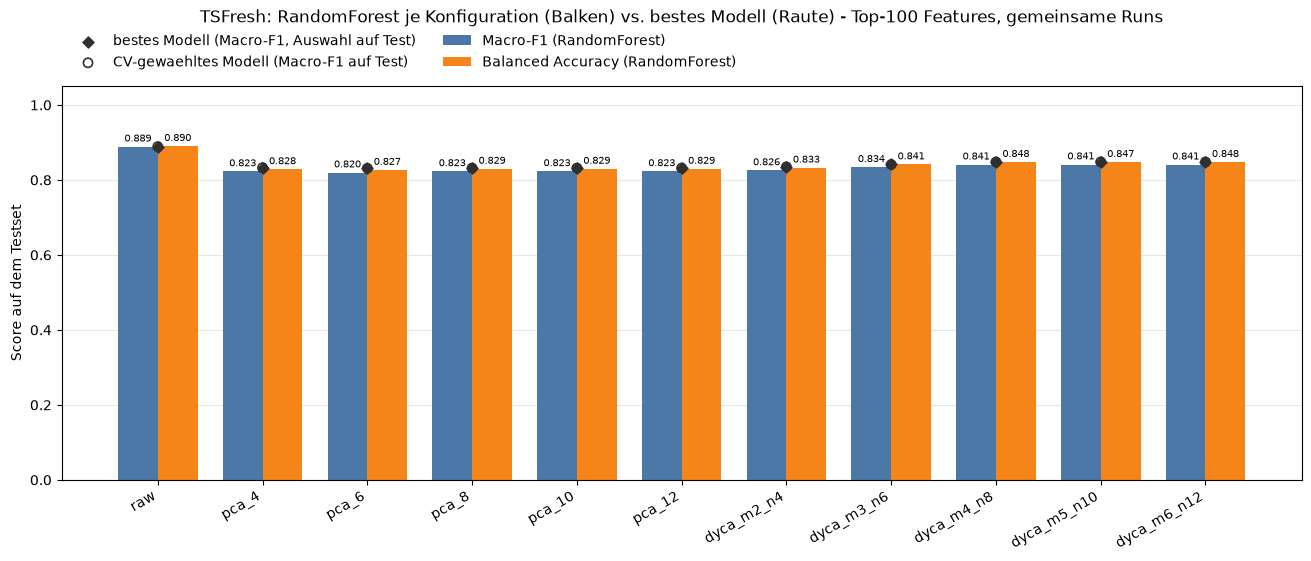

In [11]:
# ============================================================
# Plot: Hauptvergleich (RandomForest) + bestes Modell als Marker
# ============================================================
# Balken = RandomForest (festes Modell -> Konfigurationen fair
# vergleichbar). Rauten = bestes Modell je Konfiguration, ausgewaehlt auf
# dem TESTSET (leicht optimistisch, Winner's Curse). Offene Kreise = das
# auf der Train-CV gewaehlte Modell, ebenfalls mit seinem TESTwert - die
# Luecke zwischen Raute und Kreis ist der Preis des Winner's Curse.
import matplotlib.pyplot as plt

rf_d = (rf.set_index("Konfiguration").reindex(order)
        if not rf.empty else pd.DataFrame(index=order))
best_d = best_per_config.set_index("Konfiguration").reindex(order)

x = np.arange(len(order))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)

# Blau/Orange: unterscheidet sich auf der Blau-Gelb-Achse, die bei Prot-
# und Deuteranopie erhalten bleibt; Werte stehen zusaetzlich an den Balken.
b1 = ax.bar(x - w / 2, rf_d.get("MacroF1", pd.Series(np.nan, index=order)),
            w, label="Macro-F1 (RandomForest)", color="#4C78A8", zorder=2)
b2 = ax.bar(x + w / 2, rf_d.get("BalancedAcc", pd.Series(np.nan, index=order)),
            w, label="Balanced Accuracy (RandomForest)", color="#F58518",
            zorder=2)
for bars in (b1, b2):
    vals = [b.get_height() for b in bars]
    ax.bar_label(bars, labels=["" if np.isnan(v) else f"{v:.3f}" for v in vals],
                 fontsize=7, padding=2)

# Bestes Modell je Konfiguration als Raute (nur Macro-F1, die Kernzahl).
ax.scatter(x, best_d["MacroF1"], marker="D", s=32, color="#2f2f2f", zorder=3,
           label="bestes Modell (Macro-F1, Auswahl auf Test)")

# Das auf der Train-CV gewaehlte Modell als offener Kreis - gezeigt wird
# sein TESTwert. cv_best kommt aus der Vergleichszelle und ist None, wenn
# ohne CV gelaufen wurde (LC_CV_FOLDS = 0).
try:
    cv_best
except NameError:
    cv_best = None
if cv_best is not None:
    cv_d = cv_best.set_index("Konfiguration").reindex(order)
    ax.scatter(x, cv_d["MacroF1"], marker="o", s=44, facecolors="none",
               edgecolors="#2f2f2f", linewidths=1.2, zorder=4,
               label="CV-gewaehltes Modell (Macro-F1 auf Test)")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("Score auf dem Testset")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Legende ueber der Achse (3 Eintraege -> 2 Zeilen); pad haelt den Titel
# frei. Im Plot selbst wuerde sie Balken oder Marker verdecken.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False)
ax.set_title(f"TSFresh: RandomForest je Konfiguration (Balken) vs. bestes "
             f"Modell (Raute) - Top-{TOP_K} Features, "
             f"{'gemeinsame' if RESTRICT_TO_COMMON_RUNS else 'alle'} Runs",
             pad=46)

plt.show()


## Confusion-Matrizen je Konfiguration

Dieselbe Auswertung wie am Ende von `LazyClassifier_PCA_DyCA.ipynb`, hier über
alle 11 Konfigurationen: **ein fester Modelltyp** — RandomForest, also der
Hauptvergleich von oben — wird pro Konfiguration auf dem **gesamten**
Trainingssatz gefittet und **einmal** auf dem echten Testset ausgewertet. Die
Unterschiede zwischen den Matrizen liegen damit allein an den Features.

**Warum neu gefittet wird.** Phase C berechnet die Vorhersagen zwar schon
(`predictions=True`), überschreibt `preds` aber je Konfiguration und hebt nichts
davon auf. Ein einzelner RF-Fit je Konfiguration auf `TOP_K = 100` Features
kostet Sekunden bis rund eine Minute — deutlich billiger, als Phase C mit ~25
Modellen zu wiederholen. Die Zelle gleicht am Ende gegen `tsfresh_summary.csv`
ab, ob sie die dortige RandomForest-Zeile reproduziert.

**Datenbasis identisch zu Phase C:** gemeinsame Runs
(`RESTRICT_TO_COMMON_RUNS`), dieselbe NaN/inf-Behandlung, `StandardScaler` +
RandomForest wie lazypredict intern. Die gemeinsamen Runs werden hier neu
bestimmt — die Zelle läuft also auch ohne vorher gelaufenes Phase C, solange
`train_top`/`test_top` aus Phase A/B im Kernel liegen.

> Der `StandardScaler` in dieser Pipeline ist **nicht** `SCALING_MODE` — er
> standardisiert die 100 TSFresh-Features vor dem Klassifizierer (so macht es
> lazypredict intern) und läuft in beiden Skalierungsmodi gleich.
> `SCALING_MODE = "scaler"` betrifft die Vorverarbeitung **vor** der Projektion,
> ist also längst in den Features eingebacken, die hier ankommen.

**Darstellung.** Die Matrizen sind **zeilenweise normiert** (Zeilensumme = 1):
Zelle (i, j) ist der Anteil der wahren Klasse *i*, der als *j* vorhergesagt
wurde, die Diagonale also der Recall. Alle Panels teilen sich die Skala 0…1 und
sind dadurch direkt vergleichbar. Die absoluten Zählwerte stehen als
21×21-DataFrame in `cm_counts[name]`.

Die Vorhersagen werden als `tsfresh_cm_predictions.csv` im Cache abgelegt — hier
also in `tsfresh_cache_scaler/`, getrennt von der gleichnamigen Datei des
`global_mean`-Laufs in `tsfresh_cache/`. Beide lassen sich damit direkt
gegeneinanderlegen (siehe letzte Zelle). Nach einem Kernel-Neustart laufen die
Plotzellen darunter ohne Phase A/B/C; `CM_REFIT = True` erzwingt die
Neuberechnung.

In [12]:
# ============================================================
# Confusion-Matrizen: RandomForest je Konfiguration
# ============================================================
# Wie am Ende von LazyClassifier_PCA_DyCA.ipynb, hier ueber alle
# Konfigurationen dieses Notebooks. Fester Modelltyp (RandomForest, wie im
# Hauptvergleich) -> die Unterschiede zwischen den Matrizen liegen allein
# an den Features.
#
# Datenbasis exakt wie Phase C: gemeinsame Runs, gleiche NaN-Behandlung,
# StandardScaler + RandomForest (wie lazypredict intern). Die gemeinsamen
# Runs werden hier neu bestimmt, damit die Zelle auch OHNE gelaufenes
# Phase C funktioniert - es reichen train_top/test_top aus Phase A/B.
#
# CM_REFIT=False nutzt den Vorhersage-Cache; nach einem Kernel-Neustart
# laufen die Plotzellen darunter damit ganz ohne Phase A/B/C.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CM_REFIT    = False                  # True = Cache ignorieren und neu fitten
CM_PRED_CSV = "tsfresh_cm_predictions.csv"        # Vorhersage-Cache im CACHE_DIR
LABELS      = list(range(21))        # Fault-Klassen 0..20, feste Achsenreihenfolge

cm_order     = [config_name(c) for c in CONFIGS]
cm_pred_path = os.path.join(CACHE_DIR, CM_PRED_CSV)

if os.path.exists(cm_pred_path) and not CM_REFIT:
    cm_pred = pd.read_csv(cm_pred_path)
    print(f"Vorhersagen aus {cm_pred_path} geladen "
          f"({cm_pred['Konfiguration'].nunique()} Konfigurationen, "
          f"{len(cm_pred)} Zeilen). CM_REFIT=True erzwingt Neuberechnung.")
else:
    try:
        train_top, test_top
    except NameError:
        raise RuntimeError(
            "train_top/test_top fehlen und es gibt keinen Vorhersage-Cache -> "
            "zuerst Phase A und B ausfuehren (laufen aus dem Chunk-Cache).")

    # Gemeinsame Runs - identische Logik wie in Phase C.
    if RESTRICT_TO_COMMON_RUNS:
        idx_tr = sorted(set.intersection(*(set(d.index) for d in train_top.values())))
        idx_te = sorted(set.intersection(*(set(d.index) for d in test_top.values())))
        print(f"Gemeinsame Runs: Train {len(idx_tr)}, Test {len(idx_te)}")
    else:
        idx_tr = idx_te = None

    parts = []
    for name in cm_order:
        t0 = time.perf_counter()
        Xtr, Xte = train_top[name], test_top[name]
        if RESTRICT_TO_COMMON_RUNS:
            Xtr, Xte = Xtr.loc[idx_tr], Xte.loc[idx_te]

        ytr = labels_from_index(Xtr.index).to_numpy()
        yte = labels_from_index(Xte.index).to_numpy()
        # NaN/inf koennen aus Featureberechnungen stammen -> auffuellen.
        Xtr_v = np.nan_to_num(Xtr.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)
        Xte_v = np.nan_to_num(Xte.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)

        # Fit auf dem GANZEN Trainingssatz, danach genau EINE Auswertung
        # auf dem echten Testset.
        model = make_pipeline(StandardScaler(),
                              RandomForestClassifier(random_state=42, n_jobs=-1))
        model.fit(Xtr_v, ytr)
        y_pred = model.predict(Xte_v)

        parts.append(pd.DataFrame({"Konfiguration": name,
                                   "run_id": np.asarray(Xte.index),
                                   "y_true": yte,
                                   "y_pred": y_pred}))
        print(f"[{name:14s}] MacroF1 "
              f"{f1_score(yte, y_pred, average='macro', zero_division=0):.4f} | "
              f"BA {balanced_accuracy_score(yte, y_pred):.4f} "
              f"({time.perf_counter() - t0:.0f} s)")

    cm_pred = pd.concat(parts, ignore_index=True)
    cm_pred.to_csv(cm_pred_path, index=False)
    print(f"\nVorhersagen gespeichert: {cm_pred_path}")

# --- Matrizen aufbauen -------------------------------------------------
# labels=LABELS erzwingt die Reihenfolge 0..20 auch fuer Klassen, die nie
# vorhergesagt werden -> alle Matrizen sind deckungsgleich.
cm_results, cm_counts = {}, {}
for name in cm_order:
    g = cm_pred[cm_pred["Konfiguration"] == name]
    if g.empty:
        continue
    cm = confusion_matrix(g["y_true"], g["y_pred"], labels=LABELS)
    # Zeilenweise normiert: Zelle (i,j) = Anteil der wahren Klasse i, der
    # als j vorhergesagt wurde; Diagonale = Recall.
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros(cm.shape, dtype=float),
                        where=row_sums > 0)
    cm_results[name] = {
        "cm": cm, "cm_norm": cm_norm, "n_test": len(g),
        "bal_acc":  balanced_accuracy_score(g["y_true"], g["y_pred"]),
        "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro",
                             zero_division=0),
    }
    cm_counts[name] = pd.DataFrame(cm, index=[f"true_{i}" for i in LABELS],
                                   columns=[f"pred_{i}" for i in LABELS])

# Abgleich mit Phase C: dieser RF muss die RandomForest-Zeile aus summary
# reproduzieren. Kleine Abweichungen sind normal (RF-Zufallskomponente,
# lazypredict haengt zusaetzlich einen SimpleImputer vor den Scaler).
_sum_path = os.path.join(CACHE_DIR, "tsfresh_summary.csv")
if os.path.exists(_sum_path):
    _rf = pd.read_csv(_sum_path)
    _rf = _rf[_rf["Modell"] == "RandomForestClassifier"].set_index("Konfiguration")
    _d = {n: abs(cm_results[n]["macro_f1"] - _rf.loc[n, "MacroF1"])
          for n in cm_results if n in _rf.index}
    if _d:
        _w = max(_d, key=_d.get)
        print(f"Abgleich mit Phase C: groesste Macro-F1-Abweichung "
              f"{_d[_w]:.4f} ({_w})")

print(f"\n{len(cm_results)} Matrizen berechnet. Absolute Zaehlwerte stehen "
      f"in cm_counts, z.B. cm_counts['{cm_order[0]}'].")

Gemeinsame Runs: Train 10459, Test 10446
[raw           ] MacroF1 0.8888 | BA 0.8903 (3 s)
[pca_4         ] MacroF1 0.8228 | BA 0.8283 (3 s)
[pca_6         ] MacroF1 0.8197 | BA 0.8265 (3 s)
[pca_8         ] MacroF1 0.8231 | BA 0.8295 (3 s)
[pca_10        ] MacroF1 0.8231 | BA 0.8295 (3 s)
[pca_12        ] MacroF1 0.8231 | BA 0.8295 (3 s)
[dyca_m2_n4    ] MacroF1 0.8255 | BA 0.8326 (3 s)
[dyca_m3_n6    ] MacroF1 0.8341 | BA 0.8413 (3 s)
[dyca_m4_n8    ] MacroF1 0.8409 | BA 0.8476 (3 s)
[dyca_m5_n10   ] MacroF1 0.8412 | BA 0.8475 (3 s)
[dyca_m6_n12   ] MacroF1 0.8409 | BA 0.8476 (3 s)

Vorhersagen gespeichert: tsfresh_cache_scaler\tsfresh_cm_predictions.csv
Abgleich mit Phase C: groesste Macro-F1-Abweichung 0.0000 (raw)

11 Matrizen berechnet. Absolute Zaehlwerte stehen in cm_counts, z.B. cm_counts['raw'].


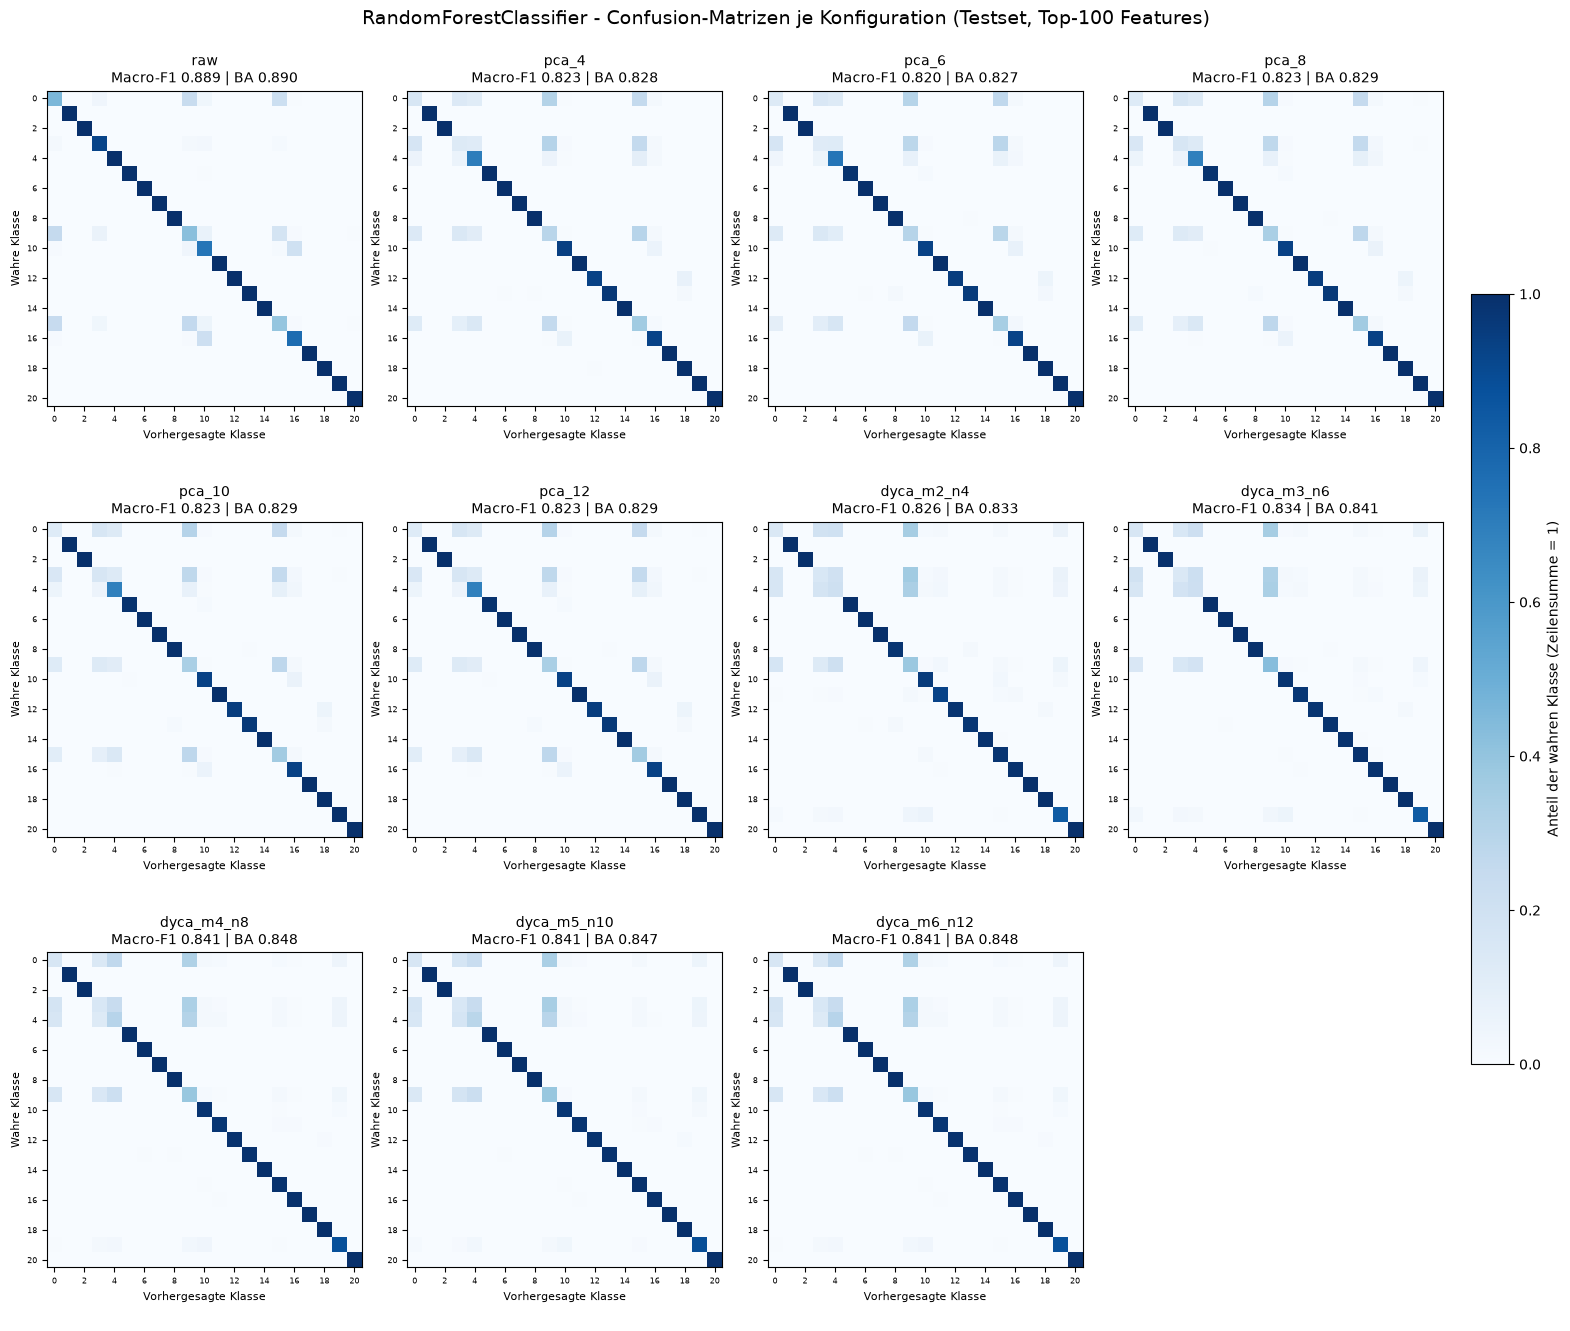

In [13]:
# ============================================================
# Plot: alle Confusion-Matrizen im Raster
# ============================================================
# Zeilenweise normiert (Zeilensumme = 1): Zelle (i, j) = Anteil der wahren
# Klasse i, der als j vorhergesagt wurde -> die Diagonale ist der Recall.
# Gemeinsame Farbskala 0..1, damit die Panels direkt vergleichbar sind.
#
# Anders als im Eigenwert-Notebook (3 Panels) werden die Zellen hier NICHT
# beschriftet - bei 11 Panels a 21x21 waere die Schrift unlesbar.
# Exakte Zahlen: cm_counts[name] bzw. das Detail-Panel darunter.
import matplotlib.pyplot as plt

CM_NCOLS = 4                      # Panels pro Zeile

names_plot = [n for n in cm_order if n in cm_results]
nrows = int(np.ceil(len(names_plot) / CM_NCOLS))

fig, axes = plt.subplots(nrows, CM_NCOLS,
                         figsize=(3.9 * CM_NCOLS, 4.4 * nrows),
                         constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, names_plot):
    res = cm_results[name]
    im = ax.imshow(res["cm_norm"], cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(f"{name}\nMacro-F1 {res['macro_f1']:.3f} | "
                 f"BA {res['bal_acc']:.3f}", fontsize=10)
    # Nur jede zweite Klasse beschriften - 21 Ticks je Achse waeren im
    # kleinen Panel eine graue Linie.
    ax.set_xticks(LABELS[::2])
    ax.set_xticklabels(LABELS[::2], fontsize=6)
    ax.set_yticks(LABELS[::2])
    ax.set_yticklabels(LABELS[::2], fontsize=6)
    ax.set_xlabel("Vorhergesagte Klasse", fontsize=8)
    ax.set_ylabel("Wahre Klasse", fontsize=8)

for ax in axes[len(names_plot):]:       # ungenutzte Panels ausblenden
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Anteil der wahren Klasse (Zeilensumme = 1)")
fig.suptitle("RandomForestClassifier - Confusion-Matrizen je Konfiguration "
             f"(Testset, Top-{TOP_K} Features)", fontsize=14)
plt.show()

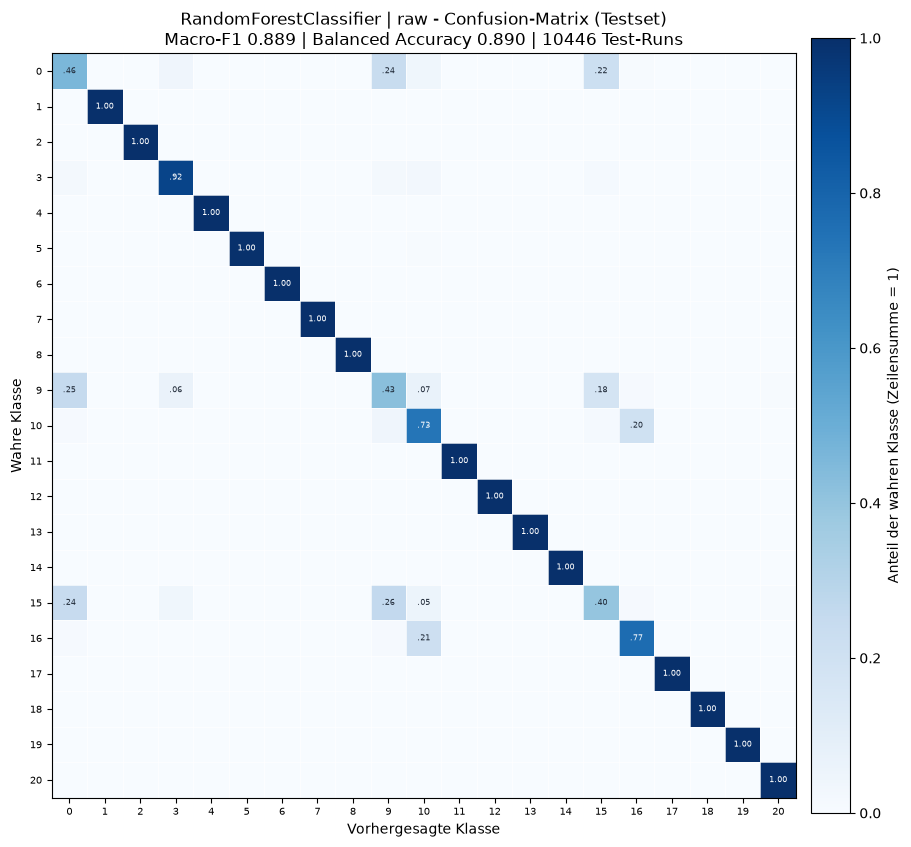

=== raw: Bericht je Klasse ===
              precision    recall  f1-score   support

           0      0.463     0.460     0.462       496
           1      1.000     1.000     1.000       499
           2      1.000     1.000     1.000       500
           3      0.866     0.922     0.893       498
           4      1.000     1.000     1.000       498
           5      0.998     0.996     0.997       497
           6      1.000     1.000     1.000       493
           7      1.000     1.000     1.000       498
           8      1.000     1.000     1.000       499
           9      0.430     0.425     0.428       496
          10      0.645     0.731     0.685       498
          11      1.000     1.000     1.000       497
          12      1.000     1.000     1.000       494
          13      1.000     1.000     1.000       496
          14      1.000     1.000     1.000       498
          15      0.483     0.396     0.435       498
          16      0.771     0.768     0.770       

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9,...,pred_11,pred_12,pred_13,pred_14,pred_15,pred_16,pred_17,pred_18,pred_19,pred_20
true_0,228,0,0,20,0,0,0,0,0,118,...,0,0,0,0,108,3,0,0,0,0
true_1,0,499,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_2,0,0,500,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_3,11,0,0,459,0,0,0,0,0,9,...,0,0,0,0,7,0,0,0,0,0
true_4,0,0,0,0,498,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_5,0,0,0,0,0,495,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_6,0,0,0,0,0,0,493,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_7,0,0,0,0,0,0,0,498,0,0,...,0,0,0,0,0,0,0,0,0,0
true_8,0,0,0,0,0,0,0,0,499,0,...,0,0,0,0,0,0,0,0,0,0
true_9,124,0,0,32,0,0,0,0,0,211,...,0,0,0,0,88,5,0,0,0,2


In [14]:
# ============================================================
# Detail: eine Konfiguration gross + groesste Verwechslungen
# ============================================================
# CM_FOCUS waehlt die Konfiguration (None = beste nach Macro-F1). Hier
# werden - wie im Eigenwert-Notebook - auffaellige Zellen beschriftet;
# alles unter ANNOT_MIN bliebe im 21x21-Raster ohnehin unlesbar.
CM_FOCUS  = None          # z.B. "raw" oder "dyca_m3_n6"; None = beste
ANNOT_MIN = 0.05          # ab diesem Anteil wird eine Zelle beschriftet
TOP_N     = 8             # so viele Verwechslungen auflisten

focus = CM_FOCUS or max(cm_results, key=lambda n: cm_results[n]["macro_f1"])
fres  = cm_results[focus]
fg    = cm_pred[cm_pred["Konfiguration"] == focus]

# figsize: imshow erzwingt ein quadratisches Panel - die Hoehe ist also
# Breite minus Colorbar/Beschriftung, plus der zweizeilige Titel. Wird die
# Figur flacher, schneidet sie die erste Titelzeile ab.
fig, ax = plt.subplots(figsize=(9, 9.2), constrained_layout=True)
im = ax.imshow(fres["cm_norm"], cmap="Blues", vmin=0.0, vmax=1.0)

ax.set_title(f"RandomForestClassifier | {focus} - Confusion-Matrix (Testset)\n"
             f"Macro-F1 {fres['macro_f1']:.3f} | "
             f"Balanced Accuracy {fres['bal_acc']:.3f} | "
             f"{fres['n_test']} Test-Runs", fontsize=12)
ax.set_xlabel("Vorhergesagte Klasse")
ax.set_ylabel("Wahre Klasse")
ax.set_xticks(LABELS)
ax.set_xticklabels(LABELS, fontsize=7)
ax.set_yticks(LABELS)
ax.set_yticklabels(LABELS, fontsize=7)

# Duenne weisse Trennlinien auf den Zellgrenzen (Minor-Ticks) - macht
# einzelne Zellen im 21x21-Raster abzaehlbar.
ax.set_xticks(np.arange(-0.5, len(LABELS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(LABELS), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", length=0)

# Selektive Beschriftung: Diagonale + relevante Verwechslungen.
# Schriftfarbe wechselt auf dunklen Zellen zu weiss (Kontrast).
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        v = fres["cm_norm"][i, j]
        if v < ANNOT_MIN:
            continue
        ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center",
                fontsize=6, color="white" if v > 0.5 else "#1f2937")

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Anteil der wahren Klasse (Zeilensumme = 1)")
plt.show()

# zero_division=0: Klassen ohne einzige Vorhersage bekommen Precision 0
# statt einer UndefinedMetricWarning.
print(f"=== {focus}: Bericht je Klasse ===")
print(classification_report(fg["y_true"], fg["y_pred"], labels=LABELS,
                            digits=3, zero_division=0))

# Die groessten Off-Diagonal-Eintraege = die systematischen Verwechslungen.
# Genau das, was man in der Grafik sucht, hier als sortierte Liste.
err = fres["cm"].astype(float).copy()
np.fill_diagonal(err, 0.0)                 # Diagonale = Treffer, nicht relevant
print(f"=== {focus}: groesste Verwechslungen (Top {TOP_N}) ===")
for flat_idx in np.argsort(err, axis=None)[::-1][:TOP_N]:
    i, j = np.unravel_index(flat_idx, err.shape)
    n_runs = int(err[i, j])
    if n_runs == 0:
        break                              # ab hier nur noch Nullen
    share = n_runs / fres["cm"][i].sum()
    print(f"  wahr {LABELS[i]:>2d} -> vorhergesagt {LABELS[j]:>2d}: "
          f"{n_runs:4d} Runs ({share:.1%} der Klasse)")

cm_counts[focus]

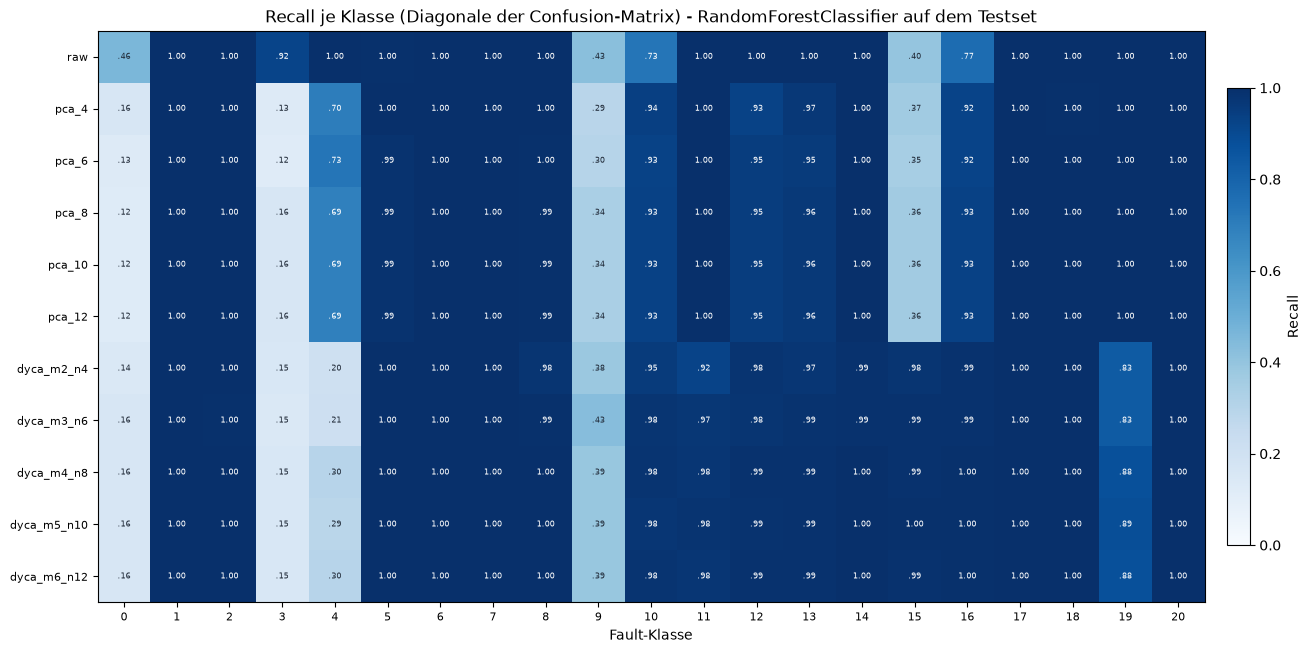

Schwierigste Klassen (mittlerer Recall ueber alle Konfigurationen):
faultNumber
0     0.173
3     0.218
9     0.364
4     0.527
15    0.649


faultNumber,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Konfiguration,,,,,,,,,,,,,,,,,,,,,
raw,0.460,1.0,1.000,0.922,1.000,0.996,1.0,1.000,1.000,0.425,...,1.000,1.000,1.000,1.000,0.396,0.768,1.0,1.000,1.000,1.0
pca_4,0.157,1.0,1.000,0.127,0.703,1.000,1.0,1.000,1.000,0.292,...,1.000,0.927,0.966,1.000,0.365,0.922,1.0,0.996,1.000,1.0
pca_6,0.127,1.0,1.000,0.118,0.731,0.988,1.0,1.000,0.996,0.300,...,1.000,0.945,0.954,1.000,0.347,0.924,1.0,0.998,1.000,1.0
pca_8,0.123,1.0,1.000,0.157,0.689,0.986,1.0,1.000,0.994,0.337,...,1.000,0.947,0.962,1.000,0.361,0.932,1.0,1.000,1.000,1.0
pca_10,0.123,1.0,1.000,0.157,0.689,0.986,1.0,1.000,0.994,0.337,...,1.000,0.947,0.962,1.000,0.361,0.932,1.0,1.000,1.000,1.0
pca_12,0.123,1.0,1.000,0.157,0.689,0.986,1.0,1.000,0.994,0.337,...,1.000,0.947,0.962,1.000,0.361,0.932,1.0,1.000,1.000,1.0
dyca_m2_n4,0.141,1.0,0.998,0.155,0.205,1.000,1.0,0.998,0.978,0.379,...,0.924,0.984,0.974,0.992,0.980,0.992,1.0,0.998,0.833,1.0
dyca_m3_n6,0.163,1.0,0.996,0.147,0.213,1.000,1.0,1.000,0.994,0.431,...,0.970,0.980,0.988,0.990,0.990,0.992,1.0,1.000,0.833,1.0
dyca_m4_n8,0.163,1.0,0.998,0.153,0.295,1.000,1.0,0.998,1.000,0.389,...,0.976,0.990,0.990,1.000,0.992,0.996,1.0,1.000,0.878,1.0


In [15]:
# ============================================================
# Recall je Fault-Klasse und Konfiguration
# ============================================================
# Die Diagonalen aller Matrizen in einer Tabelle: zeigt, WELCHE Faults eine
# Projektion traegt und welche sie verliert. Der Skalarvergleich (Macro-F1
# im Hauptvergleich) sagt das nicht - zwei Konfigurationen mit gleichem
# Mittel koennen an voellig verschiedenen Klassen scheitern.
recall_tab = pd.DataFrame(
    {name: np.diag(res["cm_norm"]) for name, res in cm_results.items()},
    index=LABELS).T
recall_tab.index.name   = "Konfiguration"
recall_tab.columns.name = "faultNumber"

fig, ax = plt.subplots(figsize=(13, 0.42 * len(recall_tab) + 1.8),
                       constrained_layout=True)
# aspect="auto": die Tabelle ist breit und flach, quadratische Zellen
# wuerden die Figur unnoetig hoch machen.
im = ax.imshow(recall_tab.to_numpy(), cmap="Blues", vmin=0.0, vmax=1.0,
               aspect="auto")

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=8)
ax.set_yticks(range(len(recall_tab)))
ax.set_yticklabels(recall_tab.index, fontsize=8)
ax.set_xlabel("Fault-Klasse")
ax.set_title("Recall je Klasse (Diagonale der Confusion-Matrix) - "
             "RandomForestClassifier auf dem Testset")

for i in range(recall_tab.shape[0]):
    for j in range(recall_tab.shape[1]):
        v = recall_tab.iat[i, j]
        ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center",
                fontsize=6, color="white" if v > 0.5 else "#1f2937")

fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02).set_label("Recall")
plt.show()

print("Schwierigste Klassen (mittlerer Recall ueber alle Konfigurationen):")
print(recall_tab.mean(axis=0).sort_values().head(5).round(3).to_string())

recall_tab.round(3)

## Wo weitergemacht werden kann

- **Feature-Namen ansehen:** `top_names["pca_8"]` zeigt, *welche* TSFresh-Features
  eine Konfiguration ausgewählt hat — oft aufschlussreicher als der Score. Die
  vollständige Rangtabelle liefert `rank_features` (dort auch `p_min`).
- **`TOP_K` variieren:** die Auswahl ist gecacht, ein anderer Wert erzwingt aber eine
  neue Selektion. Die teure Extraktion in `CACHE_DIR` bleibt gültig.
- **CV wieder abschalten:** `LC_CV_FOLDS = 0` in der Konfigurationszelle nimmt
  die 5-fache Train-CV aus Phase C heraus und spart grob das 2- bis 4-Fache der
  Phase-C-Zeit; die Modellauswahl fällt dann auf das Test-Maximum zurück. Die
  teuren Phasen A/B sind nicht betroffen und bleiben gecacht.
- **Konfigurationen kombinieren:** `pd.concat([train_top["raw"], train_top["dyca_m4_n8"]], axis=1)`
  ergibt einen gemeinsamen Feature-Satz — analog zum PCA+DyCA-Fall im
  Eigenwert-Notebook.
- **Skalierung umstellen:** `SCALING_MODE` in der Konfigurationszelle von
  `"global_mean"` auf `"scaler"` — dann in den Eigenwert-Notebooks gleichziehen
  (dort ist es die Zeile `X_scaled = ...` mit dem `# TODO`). Der Cache-Ordner
  bekommt den Modus automatisch angehängt, alte Ergebnisse werden also nicht
  überschrieben.
- **Confusion-Matrizen:** die Zellen oben halten `cm_results` (Matrizen + Scores),
  `cm_counts` (absolute Zählwerte je Konfiguration) und `recall_tab` (Recall je
  Klasse) bereit. Für ein anderes Modell dort den `RandomForestClassifier(...)`
  austauschen und `CM_REFIT = True` setzen — sonst wird der Vorhersage-Cache
  `tsfresh_cm_predictions.csv` weiterverwendet.
- **Skalierungsmodi vergleichen:** die Vorhersagen beider Läufe liegen als
  `tsfresh_cache/tsfresh_cm_predictions.csv` (`global_mean`) und
  `tsfresh_cache_scaler/tsfresh_cm_predictions.csv` (`scaler`) nebeneinander — beide laden,
  `recall_tab` je Modus bauen und die Differenz ansehen zeigt, welche
  Fault-Klassen die Standardisierung tatsächlich rettet.
